# 0. Setup

In [2]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root() # defines project root
os.chdir(PROJECT_ROOT) # go to the root

# tools for text processing
from tools import text_tools

In [3]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

In [ ]:
entities_list = [
    'Azathoth',
    'Nyarlathotep',
    'Yog-Sothoth',
    'Shub-Niggurath',
    'Cthulhu',
    'Dagon',
    'Yig',
    'Tsathoggua',
    'Old Ones',
    'Deep Ones',
    'Shoggoth',
    #'Shoggoths',
    'Mi-Go',
    'night-gaunt',
    #'night-gaunts'
    # "Cor (Colour) do Espaço" # pensar no que fazer com esse
]

artefacts = [
    "Necronomicon",
    "Shining Trapezohedron"
]

places = [
    "R’lyeh",
    "Leng",
    "Yuggoth"
]

In [13]:
entities_df = pd.DataFrame() # creates an empty DataFrame to store entities
entities_df['name'] = entities_list

# verifying quantity of texts in which each entity appears
entities_df['number_of_texts'] = [ 
    sum([text_tools.search_name('data/silver/texts/'+file, entity) for file in biblio.files]) 
    for entity in entities_list ]

entities_df
entities_df.to_csv('data/gold/entities.csv')

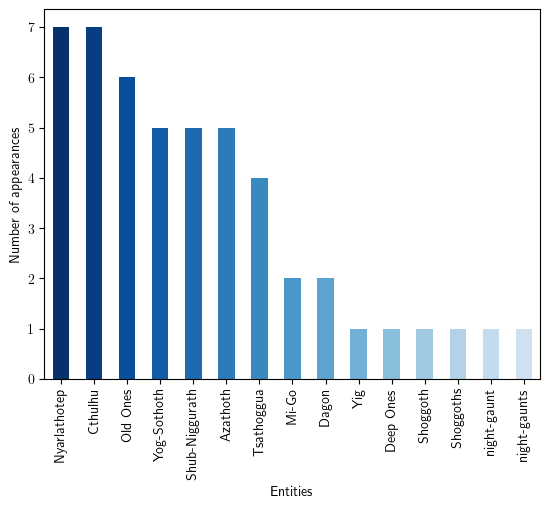

In [12]:
colors = plt.cm.Blues(np.linspace(1, 0.2, len('number_of_texts')))
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)
entities_df.plot(kind='bar',x='name',y='number_of_texts',color = colors,legend=False)
plt.xlabel('Entities')
plt.ylabel('Number of appearances')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Nyarlathotep'),
  Text(1, 0, 'Cthulhu'),
  Text(2, 0, 'Old Ones'),
  Text(3, 0, 'Yog-Sothoth'),
  Text(4, 0, 'Shub-Niggurath'),
  Text(5, 0, 'Azathoth'),
  Text(6, 0, 'Tsathoggua'),
  Text(7, 0, 'Mi-Go'),
  Text(8, 0, 'Dagon'),
  Text(9, 0, 'Yig'),
  Text(10, 0, 'Deep Ones'),
  Text(11, 0, 'Shoggoth'),
  Text(12, 0, 'Shoggoths'),
  Text(13, 0, 'night-gaunt'),
  Text(14, 0, 'night-gaunts')])

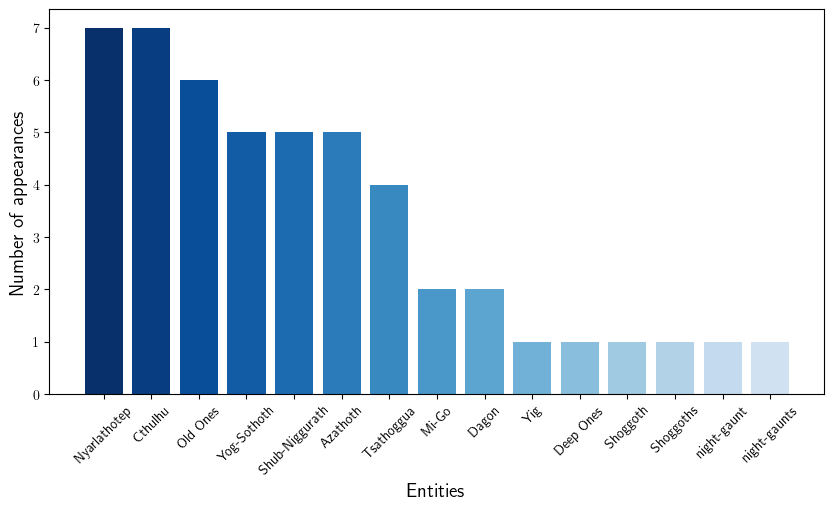

In [11]:
fig, ax = plt.subplots(figsize = (10,5))

ax.bar(entities_df['name'], entities_df['number_of_texts'], color = plt.cm.Blues(np.linspace(1, 0.2, len('number_of_texts'))))
ax.set_xlabel('Entities',fontsize = 14)
ax.set_ylabel('Number of appearances',fontsize = 14)
plt.xticks(rotation=45)

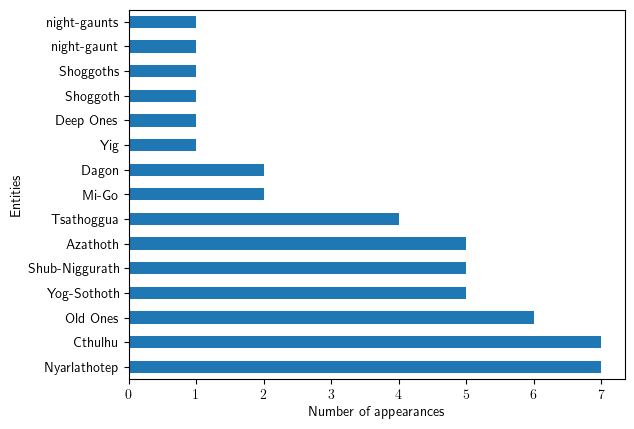

In [8]:
entities_df.plot(kind='barh',x='name',y='number_of_texts',legend=False)
plt.xlabel('Number of appearances')
plt.ylabel('Entities')
plt.show()

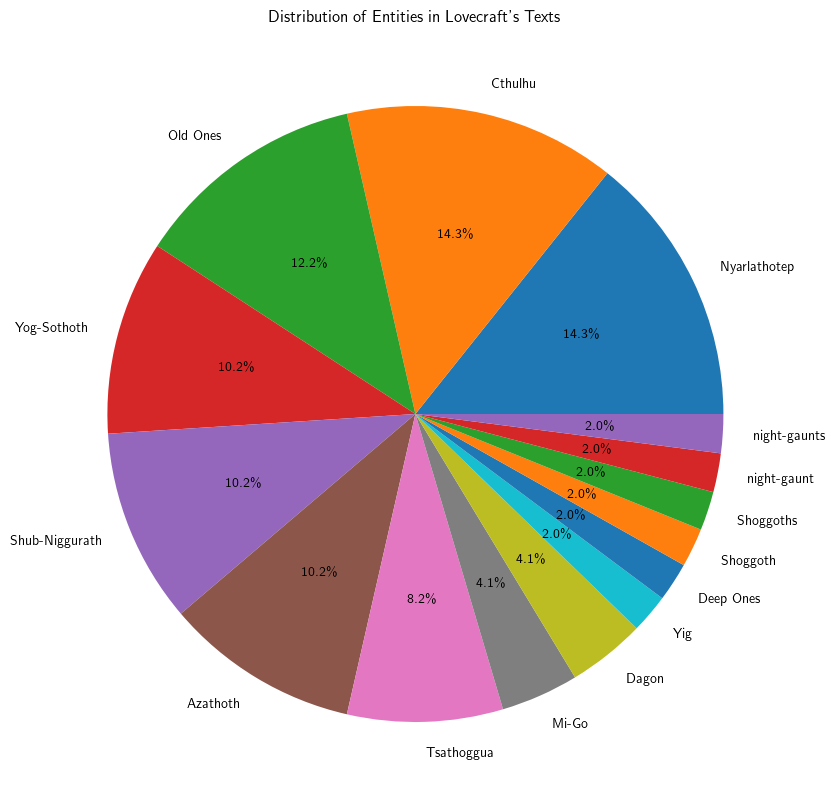

In [9]:
# plotting a pie chart of the distribution of entities in the texts
plt.figure(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values, not the percentages, to avoid the problem of small percentages being invisible in the pie chart
plt.pie(entities_df['number_of_texts'], labels=entities_df['name'], autopct='%1.1f%%') # creates a pie chart with labels and percentages
plt.title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.show() # displays the plot


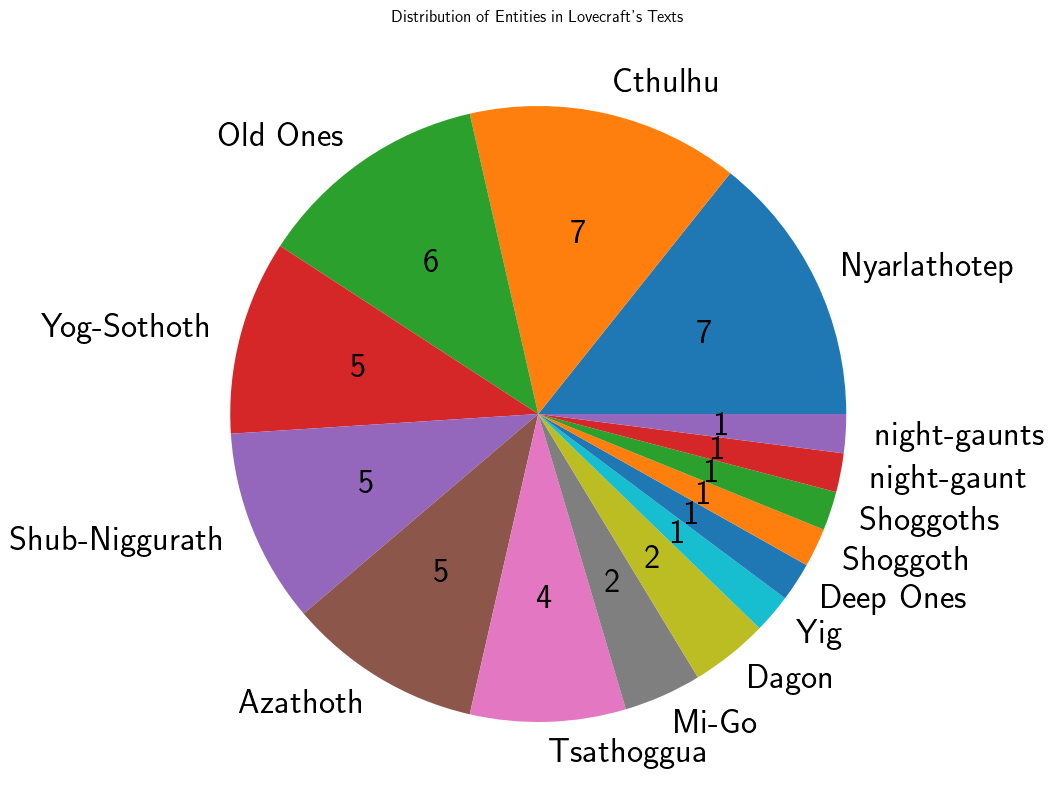

In [10]:
# plotting a pie chart of the distribution of entities in the texts
fig, ax = plt.subplots(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values in each slice label instead of percentages
total = entities_df['number_of_texts'].sum()
wedges, texts, autotexts = ax.pie(
    entities_df['number_of_texts'],
    labels=entities_df['name'],
    autopct=lambda pct: str(int(round(pct * total / 100))),
    textprops={'fontsize': 25}
)

# custom legend showing entity names and counts with a larger font size
legend_labels = [f"{name}: {count}" for name, count in zip(entities_df['name'], entities_df['number_of_texts'])]


ax.set_title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.setp(autotexts, size=25, weight='bold')
plt.show() # displays the plot
